In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

plt.style.use('ggplot')

In [4]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive (1).zip


In [6]:
with zipfile.ZipFile('archive (1).zip', 'r') as zip_ref:
    zip_ref.extractall('.')

df = pd.read_csv("Global Superstore.csv", encoding='latin1')

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [7]:
df.head()

,Category,City,Country,Customer ID,Customer Name,Discount,Market,ji_lu-shu,Order Date,Order ID,...,Sales,Segment,Ship Date,Ship Mode,Shipping Cost,State,Sub-Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,00:00.0,CA-2011-130813,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,00:00.0,CA-2011-148614,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,111,Consumer,00:00.0,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,00:00.0,CA-2011-146969,...,6,Consumer,00:00.0,Standard Class,1.32,California,Paper,2011,North America,40


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer ID     51290 non-null  object 
 4   Customer Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   ji_lu-shu       51290 non-null  int64  
 8   Order Date      51290 non-null  object 
 9   Order ID        51290 non-null  object 
 10  Order Priority  51290 non-null  object 
 11  Product ID      51290 non-null  object 
 12  Product Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row ID          51290 non-null  int64  
 17  Sales           51290 non-null 

In [9]:
print("Rows :",df.shape[0])
print("Columns :",df.shape[1])

Rows : 51290
Columns : 27


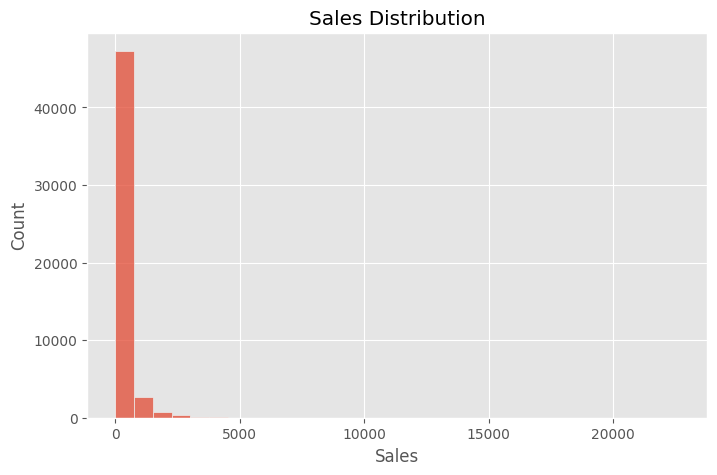

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df['Sales'],bins=30)

plt.title("Sales Distribution")

plt.show()

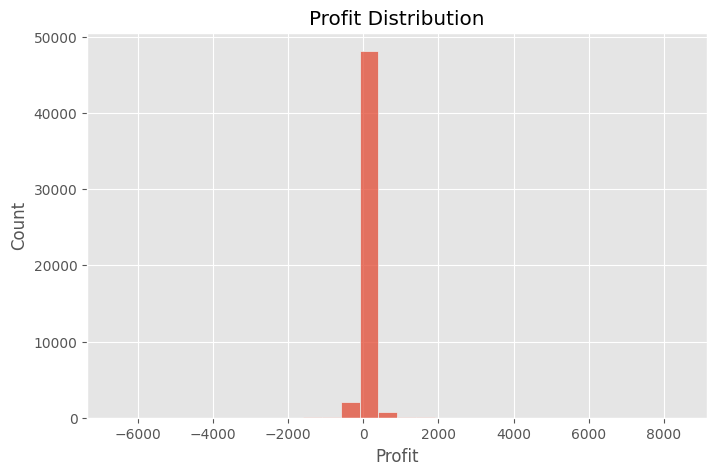

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df['Profit'],bins=30)

plt.title("Profit Distribution")

plt.show()

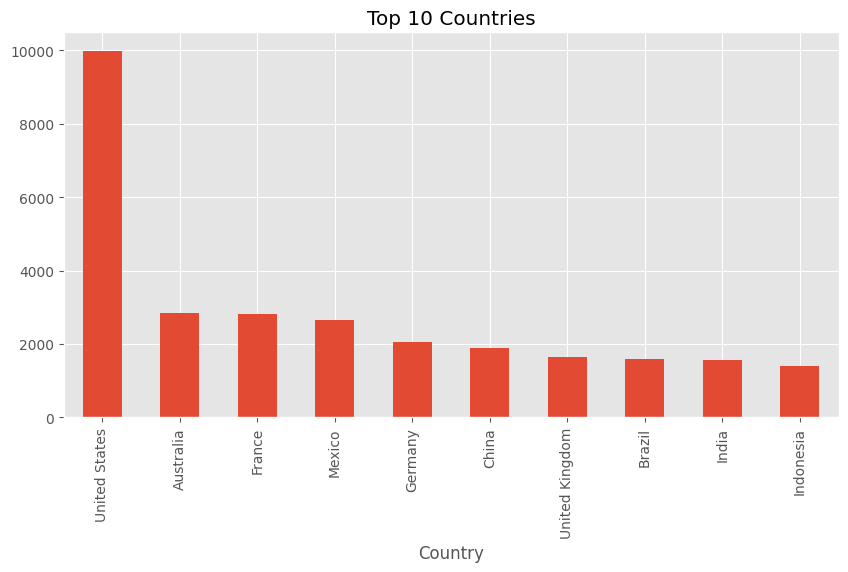

In [14]:
plt.figure(figsize=(10,5))

df['Country'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Countries")

plt.show()

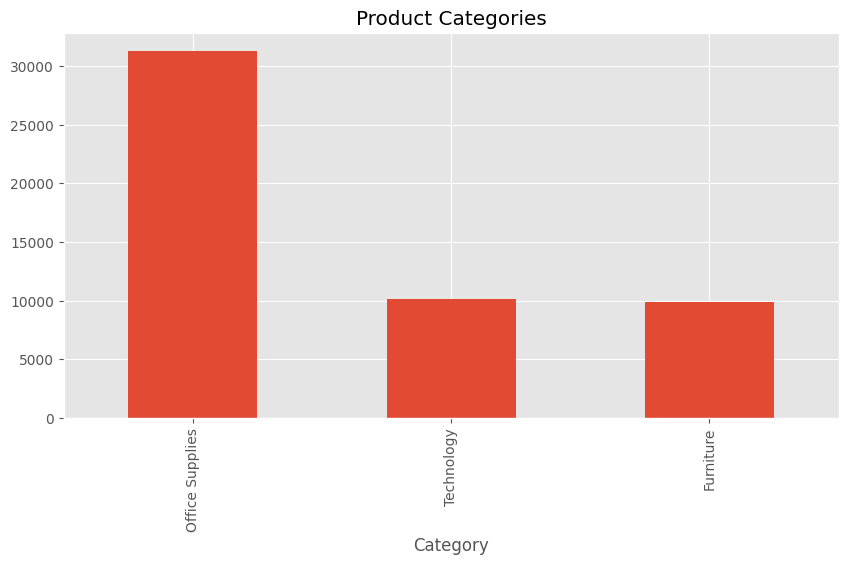

In [16]:
plt.figure(figsize=(10,5))

df['Category'].value_counts().plot(kind='bar')

plt.title("Product Categories")

plt.show()

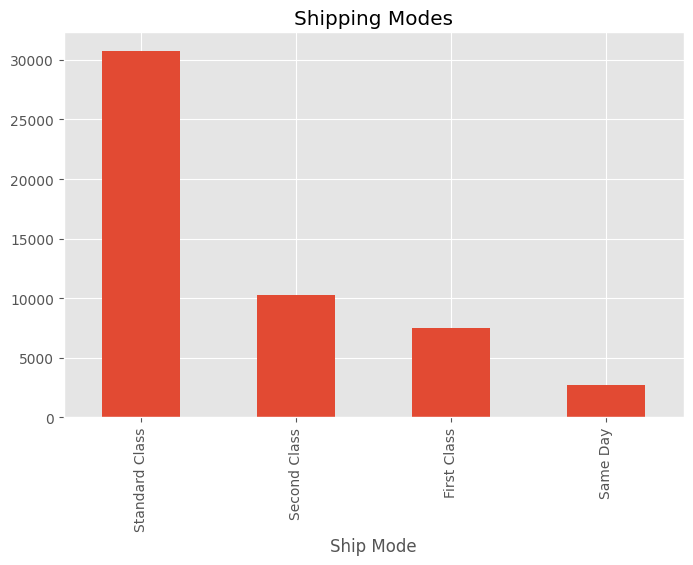

In [18]:
plt.figure(figsize=(8,5))

df['Ship Mode'].value_counts().plot(kind='bar')

plt.title("Shipping Modes")

plt.show()

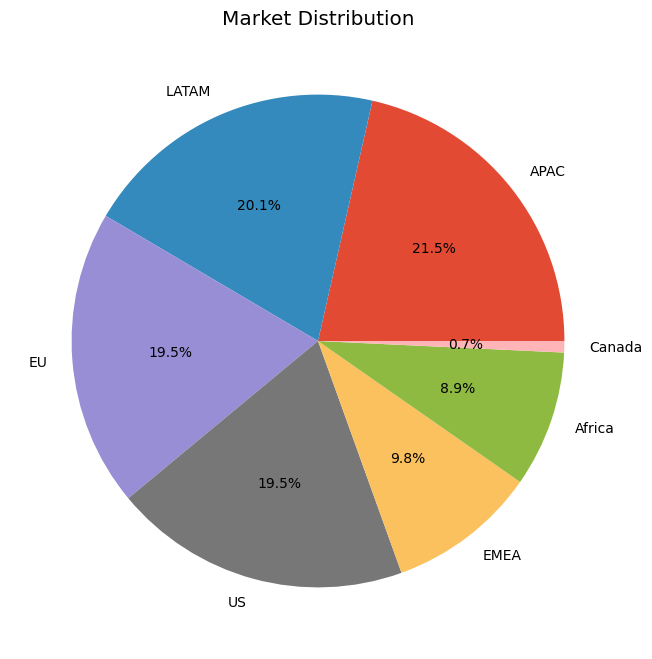

In [19]:
market=df['Market'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    market,
    labels=market.index,
    autopct='%1.1f%%'
)

plt.title("Market Distribution")

plt.show()

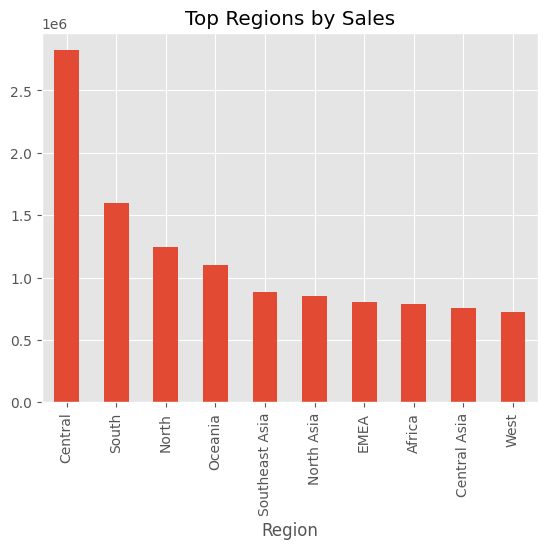

In [23]:
region=df.groupby(
    "Region"
)["Sales"].sum()

region.sort_values(
    ascending=False
).head(10).plot(kind='bar')

plt.title("Top Regions by Sales")

plt.show()

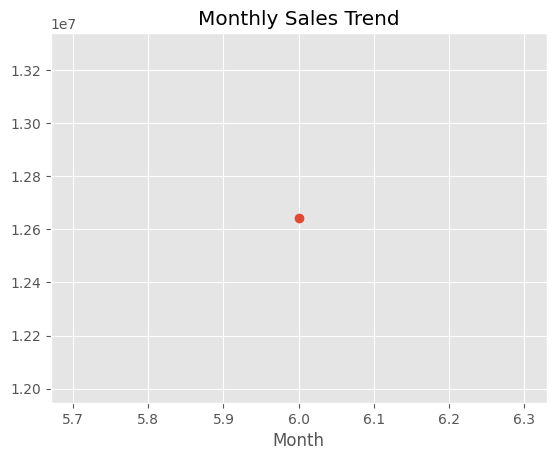

In [25]:
df['Order Date']=pd.to_datetime(
    df['Order Date']
)

df['Month']=df['Order Date'].dt.month

monthly=df.groupby(
    'Month'
)['Sales'].sum()

monthly.plot(marker='o')

plt.title("Monthly Sales Trend")

plt.show()

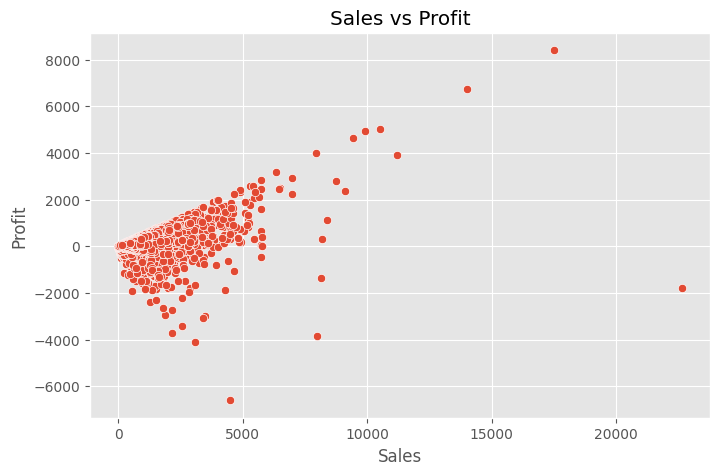

In [27]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Sales',
    y='Profit',
    data=df
)

plt.title("Sales vs Profit")

plt.show()

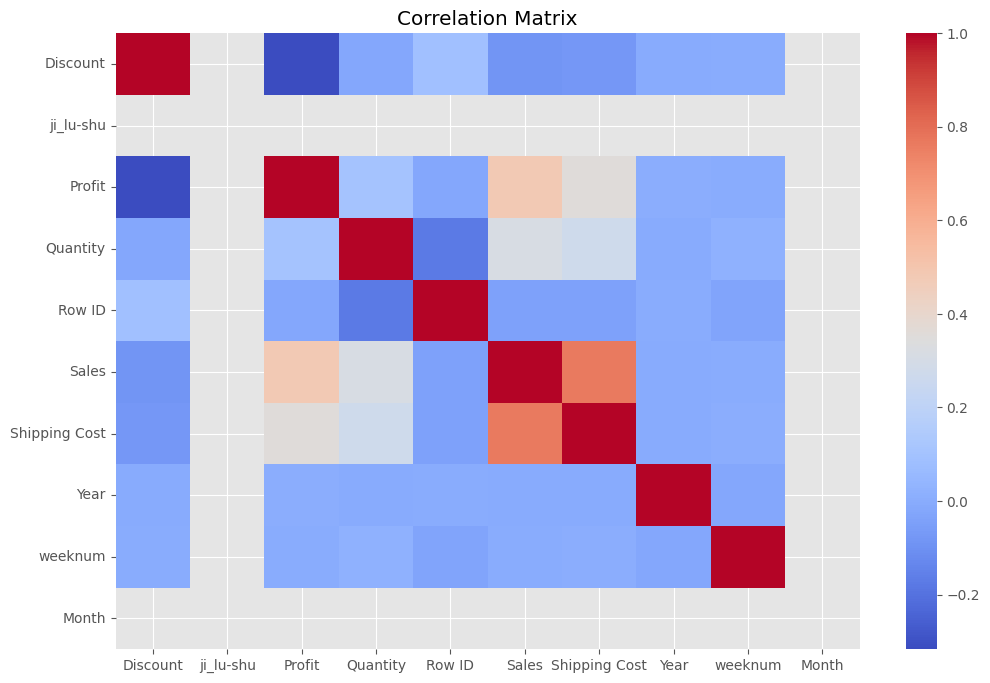

In [28]:
numeric=df.select_dtypes(include='number')

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

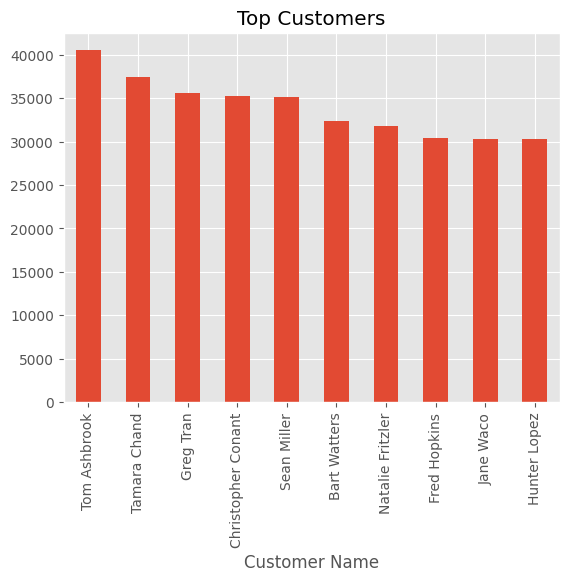

In [30]:
customer=df.groupby(
    'Customer Name'
)['Sales'].sum()

customer.sort_values(
    ascending=False
).head(10).plot(kind='bar')

plt.title("Top Customers")

plt.show()

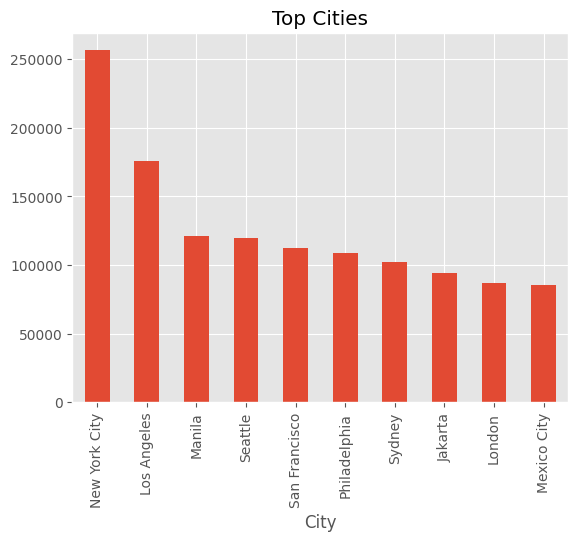

In [32]:
city=df.groupby(
    'City'
)['Sales'].sum()

city.sort_values(
    ascending=False
).head(10).plot(kind='bar')

plt.title("Top Cities")

plt.show()

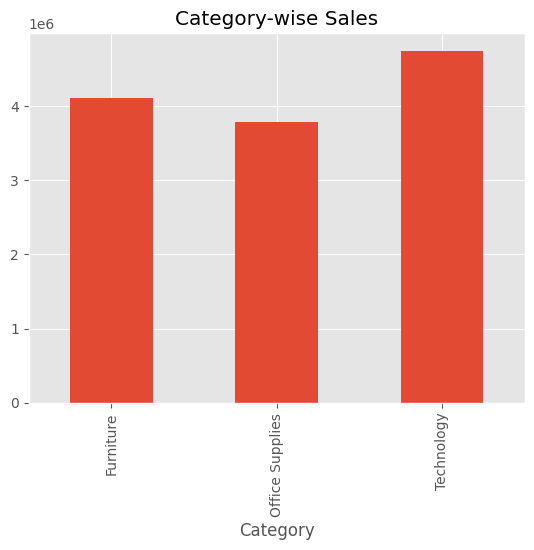

In [34]:
category=df.groupby(
    'Category'
)['Sales'].sum()

category.plot(kind='bar')

plt.title("Category-wise Sales")

plt.show()

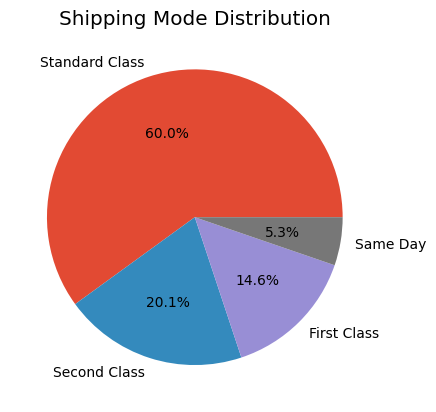

In [36]:
ship=df['Ship Mode'].value_counts()

ship.plot(kind='pie',autopct='%1.1f%%')

plt.ylabel("")

plt.title("Shipping Mode Distribution")

plt.show()

In [38]:
print("Total Orders :",len(df))

print("Total Sales :",round(df['Sales'].sum(),2))

print("Average Profit :",round(df['Profit'].mean(),2))

print("Top Market :",df['Market'].mode()[0])

print("Most Used Shipping Mode :",df['Ship Mode'].mode()[0])

print("Top Product Category :",df['Category'].mode()[0])

Total Orders : 51290
Total Sales : 12642905
Average Profit : 28.61
Top Market : APAC
Most Used Shipping Mode : Standard Class
Top Product Category : Office Supplies


In [39]:
df.to_csv(
    "DataCo_EDA.csv",
    index=False
)

print("EDA Dataset Saved Successfully")

EDA Dataset Saved Successfully


In [40]:
from google.colab import files

files.download("DataCo_EDA.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>